In [1]:
import h5py

import numpy as np
import torch

from matplotlib import pyplot as plt

import os
from tqdm import tqdm

<KeysViewHDF5 ['image', 'mask']>
(240, 240, 4) 8.12370312463885 -0.6034886502887595
	 0 6.014733693311789 -0.531526504523273
	 1 2.9789395965767107 -0.6034886502887595
	 2 8.12370312463885 -0.5715990641867276
	 3 5.433679180371389 -0.5274331116771812
(240, 240, 3) 1 0


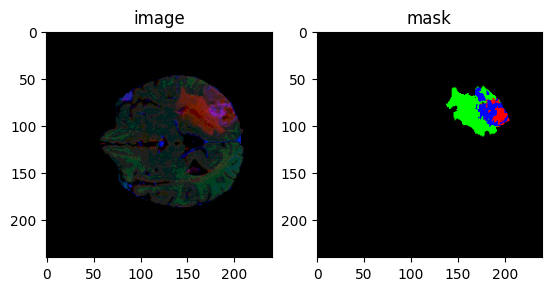

<Figure size 640x480 with 0 Axes>

In [3]:
path_to_data = "../data/BraTS2020_training_data/content/data/volume_41_slice_60.h5"

def check_h5_file(path_to_data):
    with h5py.File(path_to_data, "r") as file:
        print(file.keys())
        img = np.array(file["image"])
        print(img.shape, img.max(), img.min())
        for c in range(img.shape[2]):
            print("\t", c, img[:,:,c].max(), img[:,:,c].min())
    
        mask = np.array(file["mask"])
        print(mask.shape, mask.max(), mask.min())

        img = img[:,:,:3].astype(int)
        minv = img.min()
        maxv = img.max()

        img = (img - minv)/(maxv-minv) *255
        
        fig, axs  = plt.subplots(1, 2)
        plt.figure()
        axs[0].set_title("image")
        axs[0].imshow(img.astype(np.uint8))
        axs[1].set_title("mask")
        axs[1].imshow(mask*255)


check_h5_file(path_to_data)

In [3]:
154
#for i in range(154):
#    path_to_data = f"data/BraTS2020_training_data/content/data/volume_41_slice_{i}.h5"
#    check_h5_file(path_to_data)

154

In [4]:
def get_train_test_from_list(list_of_name, prop_of_train=0.8):
    # перемешать случайно список
    np.random.shuffle(list_of_name)
    len_of_train = int(round(prop_of_train*len(list_of_name)))+1
    return list_of_name[:len_of_train], list_of_name[len_of_train:]


In [5]:
# Установка типа девайса
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64


def mask_label_to_class_val(mask):
    if mask.sum() == 0:
        return 0
    else:
        return 1

def numpy_data_to_torch(img, mask):
    x = torch.from_numpy(img).to(device).permute(2, 0, 1).to(torch.float32)
    y = torch.tensor([mask_label_to_class_val(mask)]).to(device).to(torch.float32)

    return x, y

def gen_get_of_data(list_of_name):
    for path_to_data in list_of_name:
        with h5py.File(path_to_data, "r") as file:
            img = np.array(file["image"])
            mask = np.array(file["mask"])

            yield img, mask

def dataset_gen(list_of_name, batch_size):
    num_of_batches = len(list_of_name)//batch_size
    end_batch_size = None if len(list_of_name)%batch_size == 0 else len(list_of_name) - batch_size*num_of_batches

    gen_data = gen_get_of_data(list_of_name)
    
    for i in range(num_of_batches):
        batch_data_img = []
        batch_data_mark = []
        for b in range(batch_size):
            x,y = numpy_data_to_torch(*next(gen_data))
            batch_data_img.append(x)
            batch_data_mark.append(y)
        yield torch.stack(batch_data_img), torch.stack(batch_data_mark)

    if end_batch_size:
        batch_data_img = []
        batch_data_mark = []
        for b in range(end_batch_size):
            x,y = numpy_data_to_torch(*next(gen_data))
            batch_data_img.append(x)
            batch_data_mark.append(y)
        yield torch.stack(batch_data_img), torch.stack(batch_data_mark)

In [6]:
path_to_data = "../data/BraTS2020_training_data/content/data/"
list_of_data_names = [os.path.join(path_to_data, name_data) for name_data in os.listdir(path_to_data) if name_data.endswith(".h5")]
train_names, test_names = get_train_test_from_list(list_of_data_names)

In [10]:
print(f"use device: {device}")

# Функция вычисления точности top-1
def get_accuracy(data_loader, model):
    model.eval()
    tp = 0
    n = 0
    with torch.no_grad():
        for images, labels in data_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            
            preds = torch.round(outputs)
            n += labels.size(0)
            tp += (preds == labels).sum()

    model.train()
    return tp / n


def fit(cnn_model, train_names, num_epochs, optimizer, loss_function):
  cnn_model.train()

  for epoch in range(num_epochs):
      np.random.shuffle(train_names)
      loop = tqdm(dataset_gen(train_names, batch_size), total=len(train_names)//batch_size)

      loss_val = 0.0
      train_running_correct = 0
  
      index = 0
      for i, (images, labels) in enumerate(loop):
          index = i
          print(images.shape, labels.shape)
          
          images = images.requires_grad_()

          #print(images.shape)
          #forward 
          outputs = cnn_model(images)
          
          #print(outputs.shape)
          loss = loss_function(outputs, labels)

          preds = torch.round(outputs)

          train_running_correct += (preds == labels).sum().item() # и 0==0 и 1==1

          #backward 
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          loss_val += loss.item()

          # экономия памяти
          del images
          del labels
                                                                                                 # усреднить по батчу и по номеру 
          loop.set_description(f"Epoch [{epoch+1}/{num_epochs}], accuracy= {round(train_running_correct/ (batch_size * (i+1)), 4)}, loss= {round(loss.item(), 4)}")
      print(f"Epoch {epoch+1}: mean_epoch_accuracy = {round(train_running_correct/ (batch_size * (index+1)), 4)}, mean_epoch_loss = {round(loss_val/(index+1), 4)}")
      print()

  cnn_model.eval()
  return cnn_model

use device: cuda


In [11]:
import torch
from torch.autograd import Variable
import torchvision
import torch.nn as nn

VGG_TYPES = {'vgg11' : torchvision.models.vgg11, 
             'vgg11_bn' : torchvision.models.vgg11_bn, 
             'vgg13' : torchvision.models.vgg13, 
             'vgg13_bn' : torchvision.models.vgg13_bn, 
             'vgg16' : torchvision.models.vgg16, 
             'vgg16_bn' : torchvision.models.vgg16_bn,
             'vgg19_bn' : torchvision.models.vgg19_bn, 
             'vgg19' : torchvision.models.vgg19}


class Custom_VGG(nn.Module):

    def __init__(self,
                 ipt_size=(128, 128, 3),
                 pretrained=True, 
                 vgg_type='vgg11_bn', 
                 num_classes=1):
        super(Custom_VGG, self).__init__()

        # load convolutional part of vgg
        assert vgg_type in VGG_TYPES, "Unknown vgg_type '{}'".format(vgg_type)
        vgg_loader = VGG_TYPES[vgg_type]
        vgg = vgg_loader(weights=torchvision.models.VGG11_BN_Weights.IMAGENET1K_V1 if pretrained else None) ################################ костыль
        self.features = vgg.features

        # input change
        self.features[0] = nn.Conv2d(ipt_size[2],64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

        # init fully connected part of vgg        
        test_ipt = Variable(torch.zeros(1,ipt_size[2],ipt_size[0],ipt_size[1]))
        test_out = self.features(test_ipt)
        self.n_features = test_out.size(1) * test_out.size(2) * test_out.size(3)
        self.classifier = nn.Sequential(nn.Linear(self.n_features, 4096),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(4096, 4096),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(4096, num_classes),
                                        nn.Sigmoid()                                        
                                       )
        self._init_classifier_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _init_classifier_weights(self):
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()

In [12]:
# инициализация модели с прдедобученными весами
model_vgg = Custom_VGG(ipt_size=(240, 240, 4), pretrained=True)
model_vgg.to(device)

## блокировка обучения сборщика фич
for param in model_vgg.features.parameters():
    param.requires_grad = False

# из-за модификации инпута необходимо его перетренировать
for param in model_vgg.features[0].parameters():
    param.requires_grad = True

In [13]:
print(model_vgg)

Custom_VGG(
  (features): Sequential(
    (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPo

In [14]:
print("тренировка модели vgg11")

learning_rate_exp1 = 0.0001
num_epochs_1 = 5

print(f"learning_rate: {learning_rate_exp1}")
print(f"num_epochs: {num_epochs_1}")

print(f"use device: {device}")

model_vgg.to(device)

loss_function_exp_1 = torch.nn.MSELoss()
optimizer_exp_1_a = torch.optim.Adam(model_vgg.parameters(), lr = learning_rate_exp1)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_vgg = fit(model_vgg, train_names, num_epochs_1, optimizer_exp_1_a, loss_function_exp_1)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_vgg.state_dict(), "model_vgg_11" + '.pth')


тренировка модели vgg11
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


  0%|                                                                                          | 0/714 [00:00<?, ?it/s]

torch.Size([64, 4, 240, 240]) torch.Size([64, 1])


Epoch [1/5], accuracy= 0.5625, loss= 0.2259:   0%|                                     | 2/714 [00:01<06:07,  1.94it/s]

torch.Size([64, 4, 240, 240]) torch.Size([64, 1])


...

Epoch [1/5], accuracy= 0.5406, loss= 0.2306:   1%|▌                                   | 10/714 [00:04<04:15,  2.76it/s]

torch.Size([64, 4, 240, 240]) torch.Size([64, 1])


Epoch [1/5], accuracy= 0.5406, loss= 0.2306:   1%|▌                                   | 10/714 [00:04<05:04,  2.31it/s]

torch.Size([64, 4, 240, 240]) torch.Size([64, 1])


KeyboardInterrupt: 

In [12]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_vgg)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:17<00:00,  2.31it/s]


tensor(0.9348, device='cuda:0')

In [13]:
print("тренировка модели vgg11 (ещё 5 эпох (итого будет 10))")

learning_rate_exp1 = 0.0001
num_epochs_1 = 5

print(f"learning_rate: {learning_rate_exp1}")
print(f"num_epochs: {num_epochs_1}")

print(f"use device: {device}")

model_vgg.to(device)

loss_function_exp_1 = torch.nn.MSELoss()
optimizer_exp_1_a = torch.optim.Adam(model_vgg.parameters(), lr = learning_rate_exp1)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_vgg = fit(model_vgg, train_names, num_epochs_1, optimizer_exp_1_a, loss_function_exp_1)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_vgg.state_dict(), "model_vgg_11" + '.pth')

тренировка модели vgg11 (ещё 5 эпох (итого будет 10))
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.9489, loss= 0.0345: : 715it [05:33,  2.14it/s]                                                


Epoch 1: mean_epoch_accuracy = 0.9489, mean_epoch_loss = 0.0395



Epoch [2/5], accuracy= 0.9543, loss= 0.0687: : 715it [05:34,  2.14it/s]                                                


Epoch 2: mean_epoch_accuracy = 0.9543, mean_epoch_loss = 0.0363



...

Epoch 3: mean_epoch_accuracy = 0.9566, mean_epoch_loss = 0.0339



Epoch [4/5], accuracy= 0.9597, loss= 0.0153: : 715it [05:34,  2.14it/s]                                                


Epoch 4: mean_epoch_accuracy = 0.9597, mean_epoch_loss = 0.0321



Epoch [5/5], accuracy= 0.9637, loss= 0.0627: : 715it [05:32,  2.15it/s]                                                


Epoch 5: mean_epoch_accuracy = 0.9637, mean_epoch_loss = 0.0294

Finished Training


In [14]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_vgg)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:16<00:00,  2.34it/s]


tensor(0.9489, device='cuda:0')

vgg11
на 5 эпохах accuracy = 0.9538
на 10 эпохах accuracy= 0.9704

vgg11 c активацией сигмоид
на 5 эпохах accuracy = 0.9348
на 10 эпохах accuracy=  0.9489 

In [16]:
from torchvision.models import resnet50, ResNet50_Weights
from collections import OrderedDict

class Custom_ResNet(nn.Module):

    def __init__(self,
                 ipt_size=(128, 128, 3),
                 pretrained=True, 
                 resnet='resnet50', 
                 num_classes=1):
        super(Custom_ResNet, self).__init__()

        # load convolutional part of resnet
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        self.features = torch.nn.Sequential(OrderedDict([*(list(resnet.named_children())[:-1])]))
        # изменение входа классификатора
        self.features.conv1=nn.Conv2d(ipt_size[2], 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)       
        # изменение выхода классификатора
        # init fully connected part of resnet        
        test_ipt = Variable(torch.zeros(1,ipt_size[2],ipt_size[0],ipt_size[1]))
        test_out = self.features(test_ipt)
        self.n_features = test_out.size(1) * test_out.size(2) * test_out.size(3)
        self.classifier = nn.Sequential(nn.Linear(self.n_features, 2048),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(2048, num_classes),
                                        nn.Sigmoid()
                                       )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [17]:
# инициализация готовыми моделями
model_resnet = Custom_ResNet(ipt_size=(240, 240, 4), pretrained=True)

# блокировка обучения сборщика фич
print("Не отключен инпут и классификатор")
for param in model_resnet.features.bn1.parameters():
    param.requires_grad = False
for param in model_resnet.features.relu.parameters():
    param.requires_grad = False
for param in model_resnet.features.layer1.parameters():
    param.requires_grad = False
for param in model_resnet.features.layer2.parameters():
    param.requires_grad = False
for param in model_resnet.features.layer3.parameters():
    param.requires_grad = False
for param in model_resnet.features.layer4.parameters():
    param.requires_grad = False

print(model_resnet)

Не отключен инпут и классификатор
Custom_ResNet(
  (features): Sequential(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)

In [18]:
print("тренировка модели ResNet50")

learning_rate_exp2 = 0.0001
num_epochs_2 = 5

print(f"learning_rate: {learning_rate_exp2}")
print(f"num_epochs: {num_epochs_2}")

print(f"use device: {device}")

model_resnet.to(device)

loss_function_exp_2 = torch.nn.MSELoss()
optimizer_exp_2 = torch.optim.Adam(model_resnet.parameters(), lr = learning_rate_exp2)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_resnet = fit(model_resnet, train_names, num_epochs_2, optimizer_exp_2, loss_function_exp_2)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_resnet.state_dict(), "model_resnet" + '.pth')

тренировка модели ResNet50
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.8433, loss= 0.1294: : 715it [05:45,  2.07it/s]                                                


Epoch 1: mean_epoch_accuracy = 0.8433, mean_epoch_loss = 0.1104



Epoch [2/5], accuracy= 0.874, loss= 0.09: : 715it [05:53,  2.02it/s]                                                   


Epoch 2: mean_epoch_accuracy = 0.874, mean_epoch_loss = 0.0896



...

Epoch 3: mean_epoch_accuracy = 0.8806, mean_epoch_loss = 0.0851



Epoch [4/5], accuracy= 0.8863, loss= 0.0908: : 715it [05:52,  2.03it/s]                                                


Epoch 4: mean_epoch_accuracy = 0.8863, mean_epoch_loss = 0.0809



Epoch [5/5], accuracy= 0.8927, loss= 0.0733: : 715it [05:47,  2.06it/s]                                                

Epoch 5: mean_epoch_accuracy = 0.8927, mean_epoch_loss = 0.0778

Finished Training


In [19]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_resnet)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:16<00:00,  2.33it/s]


tensor(0.8933, device='cuda:0')

In [20]:
print("тренировка модели ResNet50 (ещё 5 эпох (итого будет 10))")

learning_rate_exp2 = 0.0001
num_epochs_2 = 5

print(f"learning_rate: {learning_rate_exp2}")
print(f"num_epochs: {num_epochs_2}")

print(f"use device: {device}")

model_resnet.to(device)

loss_function_exp_2 = torch.nn.MSELoss()
optimizer_exp_2 = torch.optim.Adam(model_resnet.parameters(), lr = learning_rate_exp2)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_resnet = fit(model_resnet, train_names, num_epochs_2, optimizer_exp_2, loss_function_exp_2)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_resnet.state_dict(), "model_resnet" + '.pth')

тренировка модели ResNet50 (ещё 5 эпох (итого будет 10))
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.8992, loss= 0.0897: : 715it [05:30,  2.16it/s]                                                


Epoch 1: mean_epoch_accuracy = 0.8992, mean_epoch_loss = 0.0732



Epoch [2/5], accuracy= 0.9018, loss= 0.0623: : 715it [05:29,  2.17it/s]                                                


Epoch 2: mean_epoch_accuracy = 0.9018, mean_epoch_loss = 0.0717



...

Epoch 3: mean_epoch_accuracy = 0.9016, mean_epoch_loss = 0.0714



Epoch [4/5], accuracy= 0.904, loss= 0.0696: : 715it [05:37,  2.12it/s]                                                 


Epoch 4: mean_epoch_accuracy = 0.904, mean_epoch_loss = 0.07



Epoch [5/5], accuracy= 0.9099, loss= 0.0768: : 715it [05:34,  2.14it/s]                                                

Epoch 5: mean_epoch_accuracy = 0.9099, mean_epoch_loss = 0.0667

Finished Training


In [21]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_resnet)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:18<00:00,  2.29it/s]


tensor(0.9097, device='cuda:0')

ResNet50
на 5 эпохах accuracy = 0.9172
на 10 эпохах accuracy= 0.9201

ResNet50 c активацией сигмоид
на 5 эпохах accuracy= 0.8933
на 10 эпохах accuracy= 0.9097

In [22]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class Custom_EfficientNet(nn.Module):

    def __init__(self,
                 ipt_size=(128, 128, 3),
                 pretrained=True, 
                 efficientnet='efficientnet_b0', 
                 num_classes=1):
        super(Custom_EfficientNet, self).__init__()

        # load convolutional part of efficientnet
        efficientnet = efficientnet_b0(weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None)
        self.features = efficientnet.features
        self.avgpool = efficientnet.avgpool

        # изменение входа классификатора
        self.features[0][0]=nn.Conv2d(ipt_size[2], 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)   

        test_ipt = Variable(torch.zeros(1,ipt_size[2],ipt_size[0],ipt_size[1]))    
        test_out =  self.avgpool(self.features(test_ipt))
        
        self.n_features = test_out.size(1) * test_out.size(2) * test_out.size(3)
        self.classifier = nn.Sequential(nn.Linear(self.n_features, 1024),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(1024, 1024),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(1024, num_classes),
                                        nn.Sigmoid()
                                       )
        self._init_classifier_weights()

    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _init_classifier_weights(self):
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()


In [23]:
# инициализация готовыми моделями
model_efficientnet = Custom_EfficientNet(ipt_size=(240, 240, 4), pretrained=True)
model_efficientnet.to(device)

# блокировка обучения сборщика фич
for param in model_efficientnet.features.parameters():
    param.requires_grad = False

# из-за модификации инпута необходимо его перетренировать
for param in model_efficientnet.features[0].parameters():
    param.requires_grad = True

print(model_efficientnet)

Custom_EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNorm

In [24]:
print("тренировка модели EfficientNet")

learning_rate_exp3 = 0.0001
num_epochs_3 = 5

print(f"learning_rate: {learning_rate_exp3}")
print(f"num_epochs: {num_epochs_3}")

print(f"use device: {device}")

model_efficientnet.to(device)

loss_function_exp_3 = torch.nn.MSELoss()
optimizer_exp_3 = torch.optim.Adam(model_efficientnet.parameters(), lr = learning_rate_exp3)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_resnet = fit(model_efficientnet, train_names, num_epochs_3, optimizer_exp_3, loss_function_exp_3)

print('Finished Training')

# сохранить только веса
torch.save(model_efficientnet.state_dict(), "model_efficientnet" + '.pth')

тренировка модели EfficientNet
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.8549, loss= 0.099: : 715it [05:33,  2.15it/s]                                                 


Epoch 1: mean_epoch_accuracy = 0.8549, mean_epoch_loss = 0.1068



Epoch [2/5], accuracy= 0.8848, loss= 0.1004: : 715it [05:36,  2.13it/s]                                                


Epoch 2: mean_epoch_accuracy = 0.8848, mean_epoch_loss = 0.0822



...

Epoch 3: mean_epoch_accuracy = 0.8953, mean_epoch_loss = 0.0751



Epoch [4/5], accuracy= 0.9009, loss= 0.0772: : 715it [05:33,  2.14it/s]                                                


Epoch 4: mean_epoch_accuracy = 0.9009, mean_epoch_loss = 0.0708



Epoch [5/5], accuracy= 0.9066, loss= 0.073: : 715it [05:32,  2.15it/s]                                                 

Epoch 5: mean_epoch_accuracy = 0.9066, mean_epoch_loss = 0.0681

Finished Training


In [25]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), model_efficientnet)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:15<00:00,  2.36it/s]


tensor(0.9122, device='cuda:0')

In [26]:
print("тренировка модели EfficientNet (ещё 5 эпох (итого будет 10))")

learning_rate_exp3 = 0.0001
num_epochs_3 = 5

print(f"learning_rate: {learning_rate_exp3}")
print(f"num_epochs: {num_epochs_3}")

print(f"use device: {device}")

model_efficientnet.to(device)

loss_function_exp_3 = torch.nn.MSELoss()
optimizer_exp_3 = torch.optim.Adam(model_efficientnet.parameters(), lr = learning_rate_exp3)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_resnet = fit(model_efficientnet, train_names, num_epochs_3, optimizer_exp_3, loss_function_exp_3)

print('Finished Training')

# сохранить только веса
torch.save(model_efficientnet.state_dict(), "model_efficientnet" + '.pth')

тренировка модели EfficientNet (ещё 5 эпох (итого будет 10))
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.9093, loss= 0.0799: : 715it [05:33,  2.14it/s]                                                


Epoch 1: mean_epoch_accuracy = 0.9093, mean_epoch_loss = 0.066



Epoch [2/5], accuracy= 0.9125, loss= 0.0546: : 715it [05:34,  2.14it/s]                                                


Epoch 2: mean_epoch_accuracy = 0.9125, mean_epoch_loss = 0.0638



...

Epoch 3: mean_epoch_accuracy = 0.9149, mean_epoch_loss = 0.0622



Epoch [4/5], accuracy= 0.917, loss= 0.0766: : 715it [05:32,  2.15it/s]                                                 


Epoch 4: mean_epoch_accuracy = 0.917, mean_epoch_loss = 0.061



Epoch [5/5], accuracy= 0.9192, loss= 0.0161: : 715it [05:31,  2.16it/s]                                                

Epoch 5: mean_epoch_accuracy = 0.9192, mean_epoch_loss = 0.0591

Finished Training


In [27]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), model_efficientnet)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:14<00:00,  2.39it/s]


tensor(0.9222, device='cuda:0')

EfficientNet b0
на 5 эпохах accuracy = 0.9219
на 10 эпохах accuracy= 0.9278

EfficientNet b0  c активацией сигмоид
на 5 эпохах accuracy = 0.9122
на 10 эпохах accuracy= 0.9222

In [28]:
from torchvision.models import densenet121, DenseNet121_Weights

class Custom_DenseNet(nn.Module):

    def __init__(self,
                 ipt_size=(128, 128, 3),
                 pretrained=True, 
                 densenet='densenet121', 
                 num_classes=1):
        super(Custom_DenseNet, self).__init__()

        # load convolutional part of efficientnet
        densenet = densenet121(weights = DenseNet121_Weights.IMAGENET1K_V1  if pretrained else None)

        self.features = densenet.features

        # изменение входа классификатора
        self.features.conv0=nn.Conv2d(ipt_size[2], 64,  kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

        test_ipt = Variable(torch.zeros(1,ipt_size[2],ipt_size[0],ipt_size[1]))    
        test_out =  self.features(test_ipt)

        self.n_features = test_out.size(1) * test_out.size(2) * test_out.size(3)
        self.classifier = nn.Sequential(nn.Linear(self.n_features, 1024),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(1024, 1024),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(1024, num_classes),
                                        nn.Sigmoid()
                                       )
        self._init_classifier_weights()

    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _init_classifier_weights(self):
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()

In [29]:
# инициализация готовыми моделями
model_densenet = Custom_DenseNet(ipt_size=(240, 240, 4), pretrained=True)
model_densenet.to(device)

# блокировка обучения сборщика фич
for param in model_densenet.features.parameters():
    param.requires_grad = False

# из-за модификации инпута необходимо его перетренировать
for param in model_densenet.features.conv0.parameters():
    param.requires_grad = True

print(model_densenet)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Sokol-PC/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|█████████████████████████████████████████████████████████████████████████████| 30.8M/30.8M [00:05<00:00, 5.60MB/s]


Custom_DenseNet(
  (features): Sequential(
    (conv0): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [30]:
print("тренировка модели DenseNet")

learning_rate_exp4 = 0.0001
num_epochs_4 = 5

print(f"learning_rate: {learning_rate_exp4}")
print(f"num_epochs: {num_epochs_4}")

print(f"use device: {device}")

model_densenet.to(device)

loss_function_exp_4 = torch.nn.MSELoss()
optimizer_exp_4 = torch.optim.Adam(model_densenet.parameters(), lr = learning_rate_exp4)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_densenet = fit(model_densenet, train_names, num_epochs_4, optimizer_exp_4, loss_function_exp_4)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_densenet.state_dict(), "model_densenet" + '.pth')

тренировка модели DenseNet
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.8725, loss= 0.0658: : 715it [05:42,  2.09it/s]                                                


Epoch 1: mean_epoch_accuracy = 0.8725, mean_epoch_loss = 0.0917



Epoch [2/5], accuracy= 0.9143, loss= 0.0612: : 715it [05:43,  2.08it/s]                                                


Epoch 2: mean_epoch_accuracy = 0.9143, mean_epoch_loss = 0.063



...

Epoch 3: mean_epoch_accuracy = 0.9275, mean_epoch_loss = 0.0536



Epoch [4/5], accuracy= 0.9366, loss= 0.0304: : 715it [05:43,  2.08it/s]                                                


Epoch 4: mean_epoch_accuracy = 0.9366, mean_epoch_loss = 0.048



Epoch [5/5], accuracy= 0.9432, loss= 0.0174: : 715it [05:42,  2.09it/s]                                                


Epoch 5: mean_epoch_accuracy = 0.9432, mean_epoch_loss = 0.0426

Finished Training


In [31]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_densenet)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:18<00:00,  2.29it/s]


tensor(0.9411, device='cuda:0')

In [32]:
print("тренировка модели DenseNet eще 5 эпох (всего будет 10)")

learning_rate_exp4 = 0.0001
num_epochs_4 = 5

print(f"learning_rate: {learning_rate_exp4}")
print(f"num_epochs: {num_epochs_4}")

print(f"use device: {device}")

model_densenet.to(device)

loss_function_exp_4 = torch.nn.MSELoss()
optimizer_exp_4 = torch.optim.Adam(model_densenet.parameters(), lr = learning_rate_exp4)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_densenet = fit(model_densenet, train_names, num_epochs_4, optimizer_exp_4, loss_function_exp_4)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_densenet.state_dict(), "model_densenet" + '.pth')

тренировка модели DenseNet eще 5 эпох (всего будет 10)
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.9498, loss= 0.0503: : 715it [05:45,  2.07it/s]                                                


Epoch 1: mean_epoch_accuracy = 0.9498, mean_epoch_loss = 0.0387



Epoch [2/5], accuracy= 0.9534, loss= 0.025: : 715it [05:44,  2.08it/s]                                                 


Epoch 2: mean_epoch_accuracy = 0.9534, mean_epoch_loss = 0.0357



...

Epoch 3: mean_epoch_accuracy = 0.9612, mean_epoch_loss = 0.0307



Epoch [4/5], accuracy= 0.9628, loss= 0.0195: : 715it [05:44,  2.07it/s]                                                


Epoch 4: mean_epoch_accuracy = 0.9628, mean_epoch_loss = 0.0292



Epoch [5/5], accuracy= 0.9663, loss= 0.0227: : 715it [05:43,  2.08it/s]                                                


Epoch 5: mean_epoch_accuracy = 0.9663, mean_epoch_loss = 0.0266

Finished Training


In [33]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_densenet)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:18<00:00,  2.28it/s]


tensor(0.9562, device='cuda:0')

DenseNet121
на 5 эпохах accuracy = 0.8341
на 10 эпохах accuracy= 0.9095

DenseNet121 с выходной активацией сигмоид
на 5 эпохах accuracy= 0.9411
на 10 эпохах accuracy= 0.9562

In [34]:
import torch.nn as nn

In [35]:
from torchvision.models import googlenet, GoogLeNet_Weights
from collections import OrderedDict

class Custom_Googlenet(nn.Module):

    def __init__(self,
                 ipt_size=(240, 240, 4),
                 pretrained=True, 
                 googlenet_type='googlenet', 
                 num_classes=1):
        super(Custom_Googlenet, self).__init__()

        # load convolutional part of efficientnet
        model_googlenet = googlenet(weights = GoogLeNet_Weights.IMAGENET1K_V1 if pretrained else None)
        #print(model_googlenet)

        layers_dict = OrderedDict()
        # Проходим по слоям и сохраняем их имена1
        for name, layer in list(model_googlenet.named_children())[:-1]:
            layers_dict[name] = layer

        # Создаем nn.Sequential из этого OrderedDict
        self.features = nn.Sequential(layers_dict)

        #print(self.features)
        # изменение входа классификатора
        self.features.conv1.conv=nn.Conv2d(ipt_size[2], 64,  kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        #print(self.features)

        test_ipt = Variable(torch.zeros(1,ipt_size[2],ipt_size[0],ipt_size[1]))    
        test_out =  self.features(test_ipt)

        self.n_features = test_out.size(1) * test_out.size(2) * test_out.size(3)
        self.classifier = nn.Sequential(nn.Linear(self.n_features, 1024),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(1024, 1024),
                                        nn.ReLU(True),
                                        nn.Dropout(),
                                        nn.Linear(1024, num_classes),
                                        nn.Sigmoid()
                                       )
        self._init_classifier_weights()
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _init_classifier_weights(self):
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()


In [36]:
# инициализация готовыми моделями
model_googlenet = Custom_Googlenet(ipt_size=(240, 240, 4), pretrained=True)
model_googlenet.to(device)

# блокировка обучения сборщика фич
for param in model_googlenet.features.parameters():
    param.requires_grad = False

# из-за модификации инпута необходимо его перетренировать
for param in model_googlenet.features.conv1.parameters():
    param.requires_grad = True

print(model_googlenet)

Custom_Googlenet(
  (features): Sequential(
    (conv1): BasicConv2d(
      (conv): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): BasicConv2d(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv3): BasicConv2d(
      (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (inception3a): Inception(
      (branch1): BasicConv2d(
        (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    

In [37]:
print("тренировка модели GoogleNet")

learning_rate_exp5 = 0.0001
num_epochs_5 = 5

print(f"learning_rate: {learning_rate_exp5}")
print(f"num_epochs: {num_epochs_5}")

print(f"use device: {device}")

model_googlenet.to(device)

loss_function_exp_5 = torch.nn.MSELoss()
optimizer_exp_5 = torch.optim.Adam(model_googlenet.parameters(), lr = learning_rate_exp5)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_googlenet = fit(model_googlenet, train_names, num_epochs_5, optimizer_exp_5, loss_function_exp_5)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_googlenet.state_dict(), "model_googlenet" + '.pth')

тренировка модели GoogleNet
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.8494, loss= 0.101: : 715it [05:17,  2.25it/s]                                                 


Epoch 1: mean_epoch_accuracy = 0.8494, mean_epoch_loss = 0.1057



Epoch [2/5], accuracy= 0.8915, loss= 0.0807: : 715it [05:18,  2.24it/s]                                                


Epoch 2: mean_epoch_accuracy = 0.8915, mean_epoch_loss = 0.079



...

Epoch 3: mean_epoch_accuracy = 0.9026, mean_epoch_loss = 0.0711



Epoch [4/5], accuracy= 0.9086, loss= 0.0655: : 715it [05:18,  2.24it/s]                                                


Epoch 4: mean_epoch_accuracy = 0.9086, mean_epoch_loss = 0.0675



Epoch [5/5], accuracy= 0.9134, loss= 0.0651: : 715it [05:18,  2.24it/s]                                                

Epoch 5: mean_epoch_accuracy = 0.9134, mean_epoch_loss = 0.0644

Finished Training


In [38]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_googlenet)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:14<00:00,  2.39it/s]


tensor(0.9195, device='cuda:0')

In [39]:
print("тренировка модели GoogleNet eще 5 эпох (всего будет 10)")

learning_rate_exp5 = 0.0001
num_epochs_5 = 5

print(f"learning_rate: {learning_rate_exp5}")
print(f"num_epochs: {num_epochs_5}")

print(f"use device: {device}")

model_googlenet.to(device)

loss_function_exp_5 = torch.nn.MSELoss()
optimizer_exp_5 = torch.optim.Adam(model_googlenet.parameters(), lr = learning_rate_exp5)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_googlenet = fit(model_googlenet, train_names, num_epochs_5, optimizer_exp_5, loss_function_exp_5)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_googlenet.state_dict(), "model_googlenet" + '.pth')

тренировка модели GoogleNet eще 5 эпох (всего будет 10)
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.9151, loss= 0.052: : 715it [05:19,  2.24it/s]                                                 


Epoch 1: mean_epoch_accuracy = 0.9151, mean_epoch_loss = 0.0629



Epoch [2/5], accuracy= 0.9186, loss= 0.056: : 715it [05:18,  2.24it/s]                                                 


Epoch 2: mean_epoch_accuracy = 0.9186, mean_epoch_loss = 0.0606



...

Epoch 3: mean_epoch_accuracy = 0.9217, mean_epoch_loss = 0.0589



Epoch [4/5], accuracy= 0.9237, loss= 0.0548: : 715it [05:18,  2.25it/s]                                                


Epoch 4: mean_epoch_accuracy = 0.9237, mean_epoch_loss = 0.0573



Epoch [5/5], accuracy= 0.9248, loss= 0.0489: : 715it [05:18,  2.25it/s]                                                

Epoch 5: mean_epoch_accuracy = 0.9248, mean_epoch_loss = 0.0563

Finished Training


In [40]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_googlenet)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:14<00:00,  2.39it/s]


tensor(0.9213, device='cuda:0')

GoogleNet
на 5 эпохах accuracy = 0.9019
на 10 эпохах accuracy= 0.9275

GoogleNet c активацией сигмоид
на 5 эпохах accuracy = 0.9195 
на 10 эпохах accuracy= 0.9213

In [41]:
from torchvision.models import swin_t, Swin_T_Weights
from collections import OrderedDict

class Custom_Transformer(nn.Module):

    def __init__(self,
                 ipt_size=(128, 128, 3),
                 pretrained=True, 
                 transformer_type='swin_t', 
                 num_classes=1):
        super(Custom_Transformer, self).__init__()

        # load convolutional part of efficientnet
        transformer_model = swin_t(weights = Swin_T_Weights.IMAGENET1K_V1  if pretrained else None)

        #print(transformer_model)


        # Создаем nn.Sequential из этого OrderedDict
        self.features = transformer_model.features
        self.norm = transformer_model.norm
        self.permute = transformer_model.permute
        self.avgpool = transformer_model.avgpool
        self.flatten = transformer_model.flatten
        self.out_activatiov = nn.Sigmoid()

        # изменение входа классификатора
        self.features[0][0]=nn.Conv2d(ipt_size[2], 96, kernel_size=(4, 4), stride=(4, 4))

        # изменение выхода классификатора
        self.head = nn.Linear(in_features=768, out_features=num_classes, bias=True)
        

        #print("_"*20)
        #print(self.features)
    
    def forward(self, x):
        x = self.features(x)
        x = self.norm(x)
        x = self.permute(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.head(x)
        x = self.out_activatiov(x)

        return x


In [42]:
# инициализация готовыми моделями
model_transformer = Custom_Transformer(ipt_size=(240, 240, 4), pretrained=True)
model_transformer.to(device)

# блокировка обучения сборщика фич
for param in model_transformer.features.parameters():
    param.requires_grad = False

# из-за модификации инпута необходимо его перетренировать
for param in model_transformer.features[0][0].parameters():
    param.requires_grad = True

print(model_transformer)

Custom_Transformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(4, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
    

In [43]:
print("тренировка модели Transformer")

learning_rate_exp6 = 0.0001
num_epochs_6 = 5

print(f"learning_rate: {learning_rate_exp6}")
print(f"num_epochs: {num_epochs_6}")

print(f"use device: {device}")

model_transformer.to(device)

loss_function_exp_6 = torch.nn.MSELoss()
optimizer_exp_6 = torch.optim.Adam(model_transformer.parameters(), lr = learning_rate_exp6)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_transformer = fit(model_transformer, train_names, num_epochs_6, optimizer_exp_6, loss_function_exp_6)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_transformer.state_dict(), "model_transformer" + '.pth')

тренировка модели Transformer
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.8135, loss= 0.0774: : 715it [05:55,  2.01it/s]                                                


Epoch 1: mean_epoch_accuracy = 0.8135, mean_epoch_loss = 0.1344



Epoch [2/5], accuracy= 0.8703, loss= 0.0676: : 715it [05:54,  2.02it/s]                                                


Epoch 2: mean_epoch_accuracy = 0.8703, mean_epoch_loss = 0.0943



...

Epoch 3: mean_epoch_accuracy = 0.8833, mean_epoch_loss = 0.0855



Epoch [4/5], accuracy= 0.891, loss= 0.091: : 715it [05:55,  2.01it/s]                                                  


Epoch 4: mean_epoch_accuracy = 0.891, mean_epoch_loss = 0.0806



Epoch [5/5], accuracy= 0.8933, loss= 0.0716: : 715it [05:55,  2.01it/s]                                                

Epoch 5: mean_epoch_accuracy = 0.8933, mean_epoch_loss = 0.0786

Finished Training


In [44]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_transformer)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:21<00:00,  2.20it/s]


tensor(0.9037, device='cuda:0')

In [45]:
print("тренировка модели Transformer eще 5 эпох (всего будет 10)")

learning_rate_exp6 = 0.0001
num_epochs_6 = 5

print(f"learning_rate: {learning_rate_exp6}")
print(f"num_epochs: {num_epochs_6}")

print(f"use device: {device}")

model_transformer.to(device)

loss_function_exp_6 = torch.nn.MSELoss()
optimizer_exp_6 = torch.optim.Adam(model_transformer.parameters(), lr = learning_rate_exp6)

print("loss_function: MSELoss")
print("optimizer: Adam")

print("Start training")
trained_model_transformer = fit(model_transformer, train_names, num_epochs_6, optimizer_exp_6, loss_function_exp_6)

print('Finished Training')

# сохранить только веса
torch.save(trained_model_transformer.state_dict(), "model_transformer" + '.pth')

тренировка модели Transformer eще 5 эпох (всего будет 10)
learning_rate: 0.0001
num_epochs: 5
use device: cuda
loss_function: MSELoss
optimizer: Adam
Start training


Epoch [1/5], accuracy= 0.8981, loss= 0.0846: : 715it [05:56,  2.01it/s]                                                


Epoch 1: mean_epoch_accuracy = 0.8981, mean_epoch_loss = 0.0752



Epoch [2/5], accuracy= 0.8995, loss= 0.0333: : 715it [05:55,  2.01it/s]                                                


Epoch 2: mean_epoch_accuracy = 0.8995, mean_epoch_loss = 0.0747



...

Epoch 3: mean_epoch_accuracy = 0.9039, mean_epoch_loss = 0.0722



Epoch [4/5], accuracy= 0.9033, loss= 0.0684: : 715it [05:56,  2.01it/s]                                                


Epoch 4: mean_epoch_accuracy = 0.9033, mean_epoch_loss = 0.0713



Epoch [5/5], accuracy= 0.9075, loss= 0.0222: : 715it [05:55,  2.01it/s]                                                

Epoch 5: mean_epoch_accuracy = 0.9075, mean_epoch_loss = 0.0696

Finished Training


In [46]:
get_accuracy(tqdm(dataset_gen(test_names, batch_size), total=len(test_names)//batch_size+1), trained_model_transformer)

100%|████████████████████████████████████████████████████████████████████████████████| 179/179 [01:21<00:00,  2.21it/s]


tensor(0.9129, device='cuda:0')

Transformer
на 5 эпохах accuracy= 0.8778
на 10 эпохах accuracy= 0.9018

Transformer c активацией сигмоид
на 5 эпохах accuracy= 0.9037
на 10 эпохах accuracy= 0.9129

In [48]:
import json
print(test_names)
with open('names_for_test_sig.json', 'w') as f:
    json.dump(test_names, f, indent=4)

['../data/BraTS2020_training_data/content/data/volume_199_slice_60.h5', '../data/BraTS2020_training_data/content/data/volume_134_slice_50.h5', '../data/BraTS2020_training_data/content/data/volume_211_slice_49.h5', '../data/BraTS2020_training_data/content/data/volume_97_slice_5.h5', '../data/BraTS2020_training_data/content/data/volume_285_slice_10.h5', '../data/BraTS2020_training_data/content/data/volume_216_slice_150.h5', '../data/BraTS2020_training_data/content/data/volume_316_slice_88.h5', '../data/BraTS2020_training_data/content/data/volume_80_slice_110.h5', '../data/BraTS2020_training_data/content/data/volume_99_slice_137.h5', '../data/BraTS2020_training_data/content/data/volume_178_slice_57.h5', '../data/BraTS2020_training_data/content/data/volume_279_slice_90.h5', '../data/BraTS2020_training_data/content/data/volume_41_slice_18.h5', '../data/BraTS2020_training_data/content/data/volume_304_slice_49.h5', '../data/BraTS2020_training_data/content/data/volume_33_slice_116.h5', '../dat

VGG11
на 5 эпохах accuracy = 0.9538
на 10 эпохах accuracy= 0.9704
VGG11 c активацией сигмоид
на 5 эпохах accuracy = 0.9348
на 10 эпохах accuracy= 0.9489


ResNet50
на 5 эпохах accuracy = 0.9172
на 10 эпохах accuracy= 0.9201
ResNet50 c активацией сигмоид
на 5 эпохах accuracy= 0.8933
на 10 эпохах accuracy= 0.9097


EfficientNet b0
на 5 эпохах accuracy = 0.9219
на 10 эпохах accuracy= 0.9278
EfficientNet b0 c активацией сигмоид
на 5 эпохах accuracy = 0.9122
на 10 эпохах accuracy= 0.9222


DenseNet121
на 5 эпохах accuracy = 0.8341
на 10 эпохах accuracy= 0.9095
DenseNet121 с выходной активацией сигмоид
на 5 эпохах accuracy= 0.9411
на 10 эпохах accuracy= 0.9562

_________________________________________________________________________
GoogleNet
на 5 эпохах accuracy = 0.9019
на 10 эпохах accuracy= 0.9275
GoogleNet c активацией сигмоид
на 5 эпохах accuracy = 0.9195
на 10 эпохах accuracy= 0.9213


Swin Transformer
на 5 эпохах accuracy= 0.8778
на 10 эпохах accuracy= 0.9018
Swin Transformer c активацией сигмоид
на 5 эпохах accuracy= 0.9037
на 10 эпохах accuracy= 0.9129